In [5]:
# STEP1
# Generating DATA

import numpy as np
import pandas as pd
import os
from pathlib import Path

n_samples = 500
seeds = [42, 50, 100, 123, 200, 300, 456, 500, 777, 1000]

# Coefficient definitions
coef_dict = {
    'AR1': [0.2, 0.9],
    'MA1': [0.2, 0.9],
    'AR5': [[0.12, 0.1, 0.08, 0.05, 0.02],  [0.25, 0.2, 0.12, 0.08, 0.04]],
    'MA5': [[0.12, 0.1, 0.08, 0.05, 0.02], [0.25, 0.2, 0.12, 0.08, 0.04]],
    'ARMA22': [{'ar': [0.12, 0.08], 'ma': [0.12, 0.08]}, 
               {'ar': [0.2, 0.12], 'ma': [0.2, 0.12]}]
}

# AR(1) generation
def gen_ar1(phi, n, seed):
    np.random.seed(seed)
    x = np.zeros(n)
    eps = np.random.normal(0, 1, n)
    x[0] = eps[0]
    for t in range(1, n):
        x[t] = phi * x[t-1] + eps[t]
    return x

# MA(1) generation
def gen_ma1(theta, n, seed):
    np.random.seed(seed)
    eps = np.random.normal(0, 1, n)
    x = np.zeros(n)
    for t in range(1, n):
        x[t] = eps[t] + theta * eps[t-1]
    x[0] = eps[0]
    return x

# AR(5) generation
def gen_ar5(phi_list, n, seed):
    np.random.seed(seed)
    x = np.zeros(n)
    eps = np.random.normal(0, 1, n)
    for i in range(5):
        x[i] = eps[i]
    for t in range(5, n):
        x[t] = sum([phi_list[j] * x[t-j-1] for j in range(5)]) + eps[t]
    return x

# MA(5) generation
def gen_ma5(theta_list, n, seed):
    np.random.seed(seed)
    eps = np.random.normal(0, 1, n)
    x = np.zeros(n)
    for t in range(n):
        x[t] = eps[t] + sum([theta_list[j] * eps[max(0, t-j-1)] for j in range(5)])
    return x

# ARMA(2,2) generation
def gen_arma22(ar_list, ma_list, n, seed):
    np.random.seed(seed)
    x = np.zeros(n)
    eps = np.random.normal(0, 1, n)
    x[0] = eps[0]
    x[1] = ar_list[0] * x[0] + eps[1] + ma_list[0] * eps[0]
    for t in range(2, n):
        x[t] = ar_list[0] * x[t-1] + ar_list[1] * x[t-2] + eps[t] + ma_list[0] * eps[t-1] + ma_list[1] * eps[t-2]
    return x

# Create folders and save data
all_data = {}

print("Generating datasets...\n")

# AR(1)
for coef in coef_dict['AR1']:
    folder = f"AR1/{coef}"
    Path(folder).mkdir(parents=True, exist_ok=True)
    for seed in seeds:
        data = gen_ar1(coef, n_samples, seed)
        fname = f"{folder}/AR1_{coef}_seed{seed}.csv"
        pd.DataFrame({'Time': range(n_samples), 'Value': data}).to_csv(fname, index=False)
        all_data[f'AR1_{coef}_seed{seed}'] = data
    print(f"✓ AR1 coef={coef}")

# MA(1)
for coef in coef_dict['MA1']:
    folder = f"MA1/{coef}"
    Path(folder).mkdir(parents=True, exist_ok=True)
    for seed in seeds:
        data = gen_ma1(coef, n_samples, seed)
        fname = f"{folder}/MA1_{coef}_seed{seed}.csv"
        pd.DataFrame({'Time': range(n_samples), 'Value': data}).to_csv(fname, index=False)
        all_data[f'MA1_{coef}_seed{seed}'] = data
    print(f"✓ MA1 coef={coef}")

# AR(5)
for i, coef in enumerate(coef_dict['AR5']):
    first_coef = coef[0]
    folder = f"AR5/{first_coef}"
    Path(folder).mkdir(parents=True, exist_ok=True)
    for seed in seeds:
        data = gen_ar5(coef, n_samples, seed)
        fname = f"{folder}/AR5_{first_coef}_seed{seed}.csv"
        pd.DataFrame({'Time': range(n_samples), 'Value': data}).to_csv(fname, index=False)
        all_data[f'AR5_{first_coef}_seed{seed}'] = data
    print(f"✓ AR5 coef={first_coef}")

# MA(5)
for i, coef in enumerate(coef_dict['MA5']):
    first_coef = coef[0]
    folder = f"MA5/{first_coef}"
    Path(folder).mkdir(parents=True, exist_ok=True)
    for seed in seeds:
        data = gen_ma5(coef, n_samples, seed)
        fname = f"{folder}/MA5_{first_coef}_seed{seed}.csv"
        pd.DataFrame({'Time': range(n_samples), 'Value': data}).to_csv(fname, index=False)
        all_data[f'MA5_{first_coef}_seed{seed}'] = data
    print(f"✓ MA5 coef={first_coef}")

# ARMA(2,2)
for i, coef_dict_val in enumerate(coef_dict['ARMA22']):
    ar = coef_dict_val['ar']
    ma = coef_dict_val['ma']
    first_coef = ar[0]
    folder = f"ARMA22/{first_coef}"
    Path(folder).mkdir(parents=True, exist_ok=True)
    for seed in seeds:
        data = gen_arma22(ar, ma, n_samples, seed)
        fname = f"{folder}/ARMA22_{first_coef}_seed{seed}.csv"
        pd.DataFrame({'Time': range(n_samples), 'Value': data}).to_csv(fname, index=False)
        all_data[f'ARMA22_{first_coef}_seed{seed}'] = data
    print(f"✓ ARMA22 coef={first_coef}")

print(f"\nTotal datasets generated: {len(all_data)}")
print("All data saved successfully!")


Generating datasets...

✓ AR1 coef=0.2
✓ AR1 coef=0.9
✓ MA1 coef=0.2
✓ MA1 coef=0.9
✓ AR5 coef=0.12
✓ AR5 coef=0.25
✓ MA5 coef=0.12
✓ MA5 coef=0.25
✓ ARMA22 coef=0.12
✓ ARMA22 coef=0.2

Total datasets generated: 100
All data saved successfully!


In [6]:
## Checking Data Stationarity
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

print("="*70)
print("DATA GENERATION VALIDATION CHECK")
print("="*70)

# Theoretical variance formulas
def theo_var_ar(phi_list):
    """AR variance: Var = sigma^2 / (1 - sum(phi)^2) [approximation]"""
    if isinstance(phi_list, list):
        phi_sum = sum(phi_list)
    else:
        phi_sum = phi_list
    return 1 / (1 - phi_sum**2) if phi_sum**2 < 1 else np.nan

def theo_var_ma(theta_list):
    """MA variance: Var = sigma^2 * (1 + sum(theta^2))"""
    if isinstance(theta_list, list):
        return 1 + sum([t**2 for t in theta_list])
    else:
        return 1 + theta_list**2

# Load and check all datasets
models = {
    'AR1': {'path': 'AR1', 'coef': [0.2,  0.9], 'type': 'ar'},
    'MA1': {'path': 'MA1', 'coef': [0.2,  0.9], 'type': 'ma'},
    'AR5': {'path': 'AR5', 'coef': [0.12, 0.25], 'type': 'ar'},
    'MA5': {'path': 'MA5', 'coef': [0.12,  0.25],'type': 'ma'},
    'ARMA22': {'path': 'ARMA22', 'coef': [0.12, 0.2], 'type': 'arma'}
}

all_checks = []

for model_name, model_info in models.items():
    print(f"\n{'='*70}")
    print(f"Model: {model_name}")
    print(f"{'='*70}")
    
    for coef in model_info['coef']:
        coef_folder = Path(f"{model_info['path']}/{coef}")
        
        if not coef_folder.exists():
            print(f"❌ ERROR: Folder not found: {coef_folder}")
            continue
        
        # Find CSV files
        csv_files = list(coef_folder.glob('*.csv'))
        
        if len(csv_files) == 0:
            print(f"❌ ERROR: No CSV files in {coef_folder}")
            continue
        
        if len(csv_files) != 10:
            print(f"⚠️ WARNING: Expected 3 seeds, found {len(csv_files)} files")
        
        # Load and check each seed
        variances = []
        means = []
        mins = []
        maxs = []
        
        for csv_file in sorted(csv_files):
            df = pd.read_csv(csv_file)
            data = df['Value'].values
            
            # Check data integrity
            if len(data) != 500:
                print(f"❌ ERROR: Wrong sample size in {csv_file.name} (got {len(data)}, expected 500)")
                continue
            
            if np.isnan(data).any() or np.isinf(data).any():
                print(f"❌ ERROR: NaN/Inf values in {csv_file.name}")
                continue
            
            variances.append(np.var(data))
            means.append(np.mean(data))
            mins.append(np.min(data))
            maxs.append(np.max(data))
        
        # Calculate metrics
        avg_var = np.mean(variances)
        avg_mean = np.mean(means)
        
        # Theoretical variance
        if model_info['type'] == 'ar':
            theo_var = theo_var_ar(coef)
        else:  # ma or arma
            theo_var = theo_var_ma(coef)
        
        var_ratio = avg_var / theo_var if theo_var > 0 else np.nan
        
        # Format output
        status = "✅ PASS" if 0.7 < var_ratio < 1.3 else "⚠️ CHECK"
        
        print(f"\n{model_name} coef={coef}:")
        print(f"  Files: {len(csv_files)} ✓")
        print(f"  Mean: {avg_mean:.4f} (should be ≈0)")
        print(f"  Observed Var: {avg_var:.4f}")
        print(f"  Theoretical Var: {theo_var:.4f}")
        print(f"  Var Ratio: {var_ratio:.4f} {status}")
        print(f"  Range: [{np.mean(mins):.2f}, {np.mean(maxs):.2f}]")
        
        all_checks.append({
            'Model': model_name,
            'Coef': coef,
            'Files': len(csv_files),
            'Mean': avg_mean,
            'Obs_Var': avg_var,
            'Theo_Var': theo_var,
            'Var_Ratio': var_ratio,
            'Status': '✅ PASS' if 0.7 < var_ratio < 1.3 else '⚠️ CHECK'
        })

# Summary table
print(f"\n{'='*70}")
print("SUMMARY TABLE")
print(f"{'='*70}\n")
summary_df = pd.DataFrame(all_checks)
print(summary_df.to_string(index=False))

# Final verdict
print(f"\n{'='*70}")
total = len(all_checks)
passed = len([x for x in all_checks if '✅' in x['Status']])
print(f"Result: {passed}/{total} checks passed")
if passed == total:
    print("✅ All datasets generated correctly!")
else:
    print(f"⚠️ {total-passed} dataset(s) need attention")
print(f"{'='*70}")


DATA GENERATION VALIDATION CHECK

Model: AR1

AR1 coef=0.2:
  Files: 10 ✓
  Mean: -0.0049 (should be ≈0)
  Observed Var: 1.0318
  Theoretical Var: 1.0417
  Var Ratio: 0.9905 ✅ PASS
  Range: [-3.18, 3.27]

AR1 coef=0.9:
  Files: 10 ✓
  Mean: -0.0297 (should be ≈0)
  Observed Var: 4.8226
  Theoretical Var: 5.2632
  Var Ratio: 0.9163 ✅ PASS
  Range: [-5.82, 5.90]

Model: MA1

MA1 coef=0.2:
  Files: 10 ✓
  Mean: -0.0047 (should be ≈0)
  Observed Var: 1.0312
  Theoretical Var: 1.0400
  Var Ratio: 0.9915 ✅ PASS
  Range: [-3.17, 3.29]

MA1 coef=0.9:
  Files: 10 ✓
  Mean: -0.0075 (should be ≈0)
  Observed Var: 1.8051
  Theoretical Var: 1.8100
  Var Ratio: 0.9973 ✅ PASS
  Range: [-4.01, 4.38]

Model: AR5

AR5 coef=0.12:
  Files: 10 ✓
  Mean: -0.0050 (should be ≈0)
  Observed Var: 1.0309
  Theoretical Var: 1.0146
  Var Ratio: 1.0161 ✅ PASS
  Range: [-3.17, 3.21]

AR5 coef=0.25:
  Files: 10 ✓
  Mean: -0.0077 (should be ≈0)
  Observed Var: 1.3025
  Theoretical Var: 1.0667
  Var Ratio: 1.2211 ✅ PAS

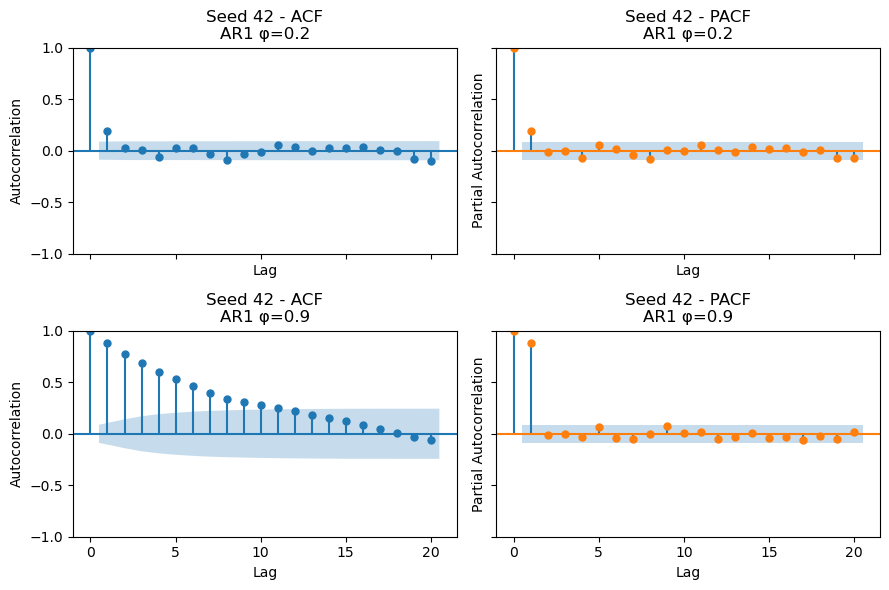

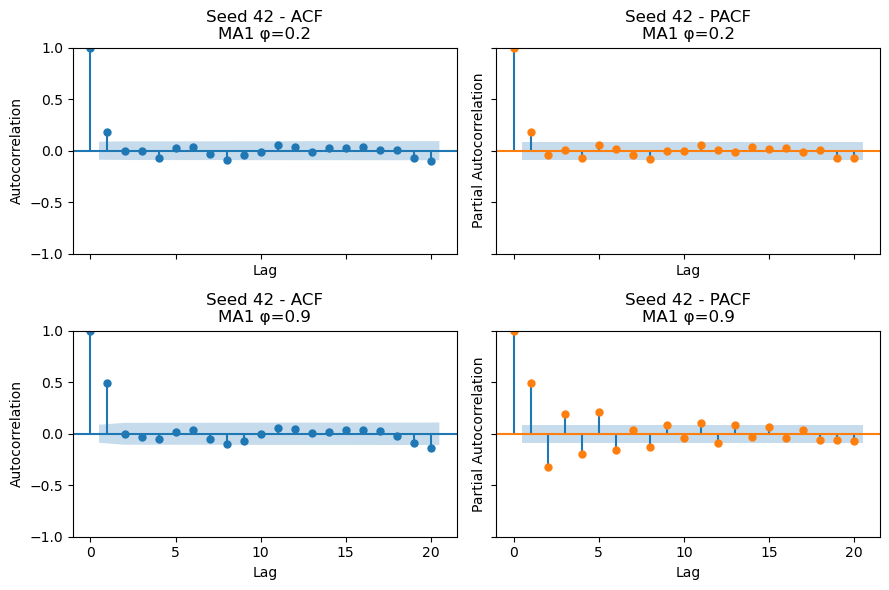

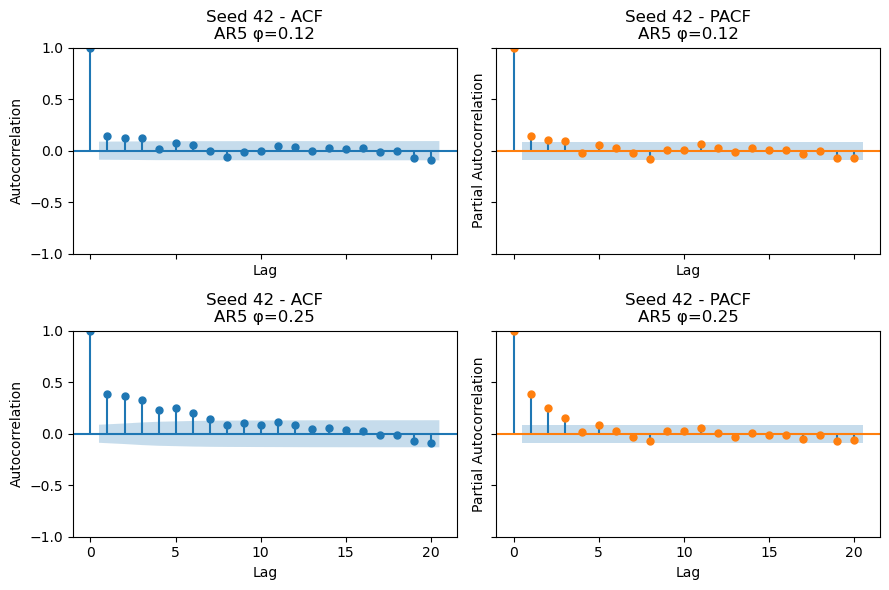

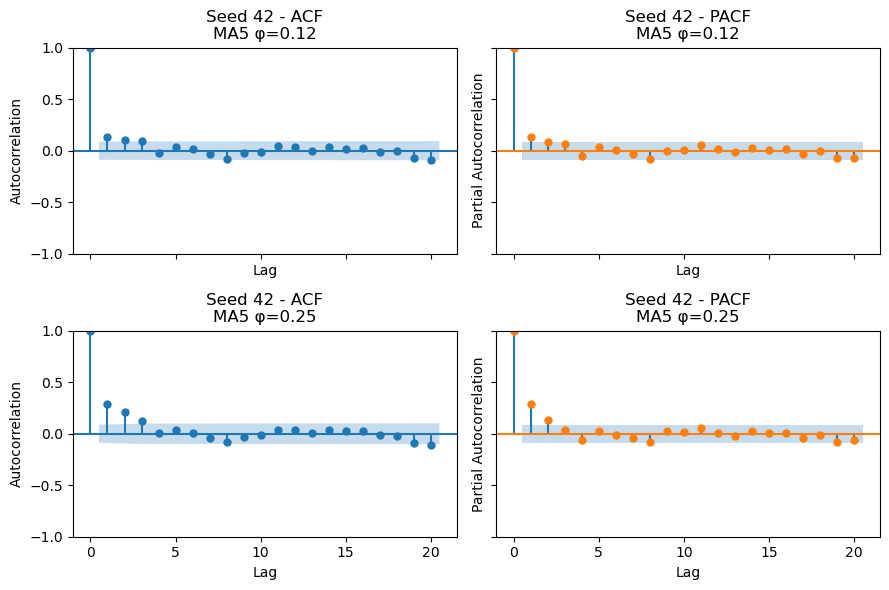

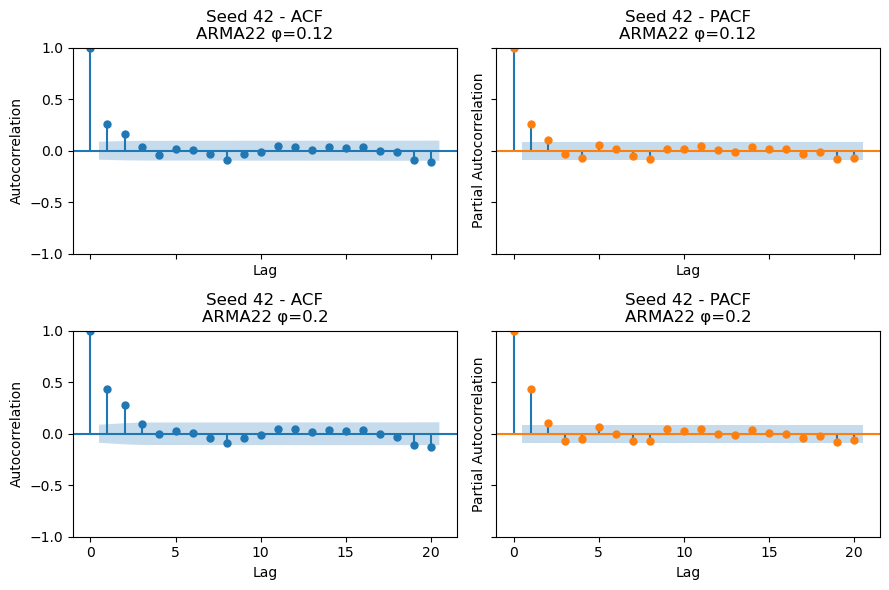

In [7]:
# STEP2
# ACF/PACF

import os
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

models = [
    ('AR1', [0.20, 0.90]),
    ('MA1', [0.20, 0.90]),
    ('AR5', [0.12, 0.25]),
    ('MA5', [0.12, 0.25]),
    ('ARMA22', [0.12, 0.20])
]
seeds = [42]

for model_name, coefs in models:
    n_models = len(coefs) * len(seeds)
    fig, axes = plt.subplots(nrows=n_models, ncols=2, figsize=(9, 3*n_models), sharex=True, sharey=True)
    plt.subplots_adjust(hspace=0.7, wspace=0.2)

    plot_idx = 0
    for coef in coefs:
        for seed in seeds:
            folder = f"{model_name}/{coef}"
            filename = f"{model_name}_{coef}_seed{seed}.csv"
            filepath = os.path.join(folder, filename)
            row_ax_acf = axes[plot_idx, 0]
            row_ax_pacf = axes[plot_idx, 1]

            if not os.path.exists(filepath):
                row_ax_acf.set_title(f"Missing {filepath}")
                row_ax_pacf.set_title(f"Missing {filepath}")
                plot_idx += 1
                continue

            df = pd.read_csv(filepath)
            series = df['Value'].values

            # ACF subplot
            plot_acf(series, lags=20, alpha=0.05, ax=row_ax_acf,
                     color='#1f77b4',
                     title=f"Seed {seed} - ACF\n{model_name} φ={coef}")
            row_ax_acf.set_xlabel('Lag')
            row_ax_acf.set_ylabel('Autocorrelation')

            # PACF subplot
            plot_pacf(series, lags=20, alpha=0.05, ax=row_ax_pacf, method='ywm',
                      color='#ff7f0e',
                      title=f"Seed {seed} - PACF\n{model_name} φ={coef}")
            row_ax_pacf.set_xlabel('Lag')
            row_ax_pacf.set_ylabel('Partial Autocorrelation')

            plot_idx += 1

    plt.tight_layout()
    plt.show()  


In [ ]:
# STEP3
# AIC / BIC

import os
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
from collections import defaultdict
import warnings
from collections import Counter

warnings.filterwarnings('ignore')

# model/coef list
models = [
    ('AR1', [0.20, 0.90]),
    ('MA1', [0.20,  0.90]),
    ('AR5', [0.12,  0.25]),
    ('MA5', [0.12,  0.25]),
    ('ARMA22', [0.12, 0.20])
]
seeds = [42, 50, 100, 123, 200, 300, 456, 500, 777, 1000]

# [(p,d,q)] list from ACF/PACF analysis
candidate_orders = [
    (1,0,0),(2,0,0),(3,0,0),(4,0,0),(5,0,0), # AR(1~5)
    (0,0,1),(0,0,2),(0,0,3),(0,0,4),(0,0,5), # MA(1~5)
    (1,0,1), (2,0,2) # ARMA(1,1), ARMA(2,2)
]
model_names = {
    (1,0,0): 'AR(1)', (2,0,0): 'AR(2)', (3,0,0): 'AR(3)', (4,0,0): 'AR(4)', (5,0,0): 'AR(5)',
    (0,0,1): 'MA(1)', (0,0,2): 'MA(2)', (0,0,3): 'MA(3)', (0,0,4): 'MA(4)', (0,0,5): 'MA(5)',
    (1,0,1): 'ARMA(1,1)', (2,0,2): 'ARMA(2,2)'
}

results = []
aic_distributions = defaultdict(lambda: defaultdict(int)) 
bic_distributions = defaultdict(lambda: defaultdict(int))

for model_name, coefs in models:
    for coef in coefs:
        for seed in seeds:
            folder = f"{model_name}/{coef}"
            filename = f"{model_name}_{coef}_seed{seed}.csv"
            filepath = os.path.join(folder, filename)
            row_result = {"Model": model_name, "Coef": coef, "Seed": seed}
            if not os.path.exists(filepath):
                row_result["Best_AIC_Model"] = "Missing"
                row_result["Best_BIC_Model"] = "Missing"
                results.append(row_result)
                continue
            df = pd.read_csv(filepath)
            series = df['Value'].values
            best_aic = 1e10
            best_bic = 1e10
            best_aic_model = None
            best_bic_model = None
            
            for order in candidate_orders:
                try:
                    fit = ARIMA(series, order=order).fit()
                    row_result[model_names[order]+'_aic'] = fit.aic
                    row_result[model_names[order]+'_bic'] = fit.bic
                    if fit.aic < best_aic:
                        best_aic = fit.aic
                        best_aic_model = model_names[order]
                    if fit.bic < best_bic:
                        best_bic = fit.bic
                        best_bic_model = model_names[order]
                except Exception as e:
                    row_result[model_names[order]+'_aic'] = None
                    row_result[model_names[order]+'_bic'] = None
            
            row_result["Best_AIC_Model"] = best_aic_model
            row_result["Best_BIC_Model"] = best_bic_model
            results.append(row_result)
            
            # (AIC) – count best model type by coefficient
            if best_aic_model and best_aic_model not in ['Missing', None]:
                try:
                    model_type = best_aic_model.split('(')[0]  # 'AR', 'MA', 'ARMA'
                    aic_distributions[coef][model_type] += 1
                except:
                    print(f"Warning: Could not parse model type from '{best_aic_model}'")
            
            # (BIC) – count best model type by coefficient
            if best_bic_model and best_bic_model not in ['Missing', None]:
                try:
                    model_type = best_bic_model.split('(')[0]  # 'AR', 'MA', 'ARMA'
                    bic_distributions[coef][model_type] += 1
                except:
                    print(f"Warning: Could not parse model type from '{best_bic_model}'")

# 1. Total table
result_df = pd.DataFrame(results)
print("=== Overall AIC/BIC result table (best model only) ===")
print(result_df[['Model', 'Coef', 'Seed', 'Best_AIC_Model', 'Best_BIC_Model']].to_string(index=False))

print("\n" + "="*80 + "\n")


from collections import Counter
import pandas as pd

def create_model_distribution_table(result_df):
    """
    Create tables showing, for each data-generating model and coefficient,
    the AIC/BIC selection distribution (in %) over candidate AR/MA/ARMA models.
    """
    tables = {'AIC': [], 'BIC': []}
    possible_models = ['AR(1)', 'AR(2)', 'AR(3)', 'AR(4)', 'AR(5)',
                      'MA(1)', 'MA(2)', 'MA(3)', 'MA(4)', 'MA(5)',
                      'ARMA(1,1)', 'ARMA(2,2)']
    criteria = ['AIC', 'BIC']

    for criterion in criteria:
        for model_name in sorted(result_df['Model'].unique()):
            subset = result_df[result_df['Model'] == model_name]
            for coef in sorted(subset['Coef'].unique()):
                coef_subset = subset[subset['Coef'] == coef]
                best_models = coef_subset[f'Best_{criterion}_Model'].dropna().tolist()

                if not best_models:
                    continue

                counts = Counter(best_models)
                total = len(best_models)
                most_common = counts.most_common(1)[0]

                row = {
                    'Model': model_name,
                    'Coef': f"{float(coef):.2f}",
                    'Criterion': criterion,
                    'Total': total,
                    'Most_Common': most_common[0],
                    'Dominant_%': round(most_common[1] / total * 100, 1)
                }

                for model_type in possible_models:
                    count = counts.get(model_type, 0)
                    row[model_type] = round((count / total) * 100, 1)

                tables[criterion].append(row)

        tables[criterion] = pd.DataFrame(tables[criterion])

    return tables

# Run function (result_df is the DataFrame created above with ARIMA results)
aic_bic_tables = create_model_distribution_table(result_df)

# AIC table output
print("=== Selection rate (%) by model type for each coefficient (AIC-based) ===")
aic_cols = ['Model', 'Coef', 'Total', 'Most_Common', 'Dominant_%',
            'AR(1)', 'MA(1)', 'ARMA(1,1)', 'AR(2)', 'MA(3)', 'AR(5)', 'ARMA(2,2)']
print(aic_bic_tables['AIC'][aic_cols].to_string(index=False))

print("\n" + "="*60 + "\n")

# BIC table output
print("=== Selection rate (%) by model type for each coefficient (BIC-based) ===")
print(aic_bic_tables['BIC'][aic_cols].to_string(index=False))


=== Overall AIC/BIC result table (best model only) ===
 Model  Coef  Seed Best_AIC_Model Best_BIC_Model
   AR1  0.20    42          AR(1)          AR(1)
   AR1  0.20    50          MA(1)          MA(1)
   AR1  0.20   100          AR(2)          AR(1)
   AR1  0.20   123          AR(1)          AR(1)
   AR1  0.20   200          MA(1)          MA(1)
   AR1  0.20   300          AR(1)          AR(1)
   AR1  0.20   456          MA(1)          MA(1)
   AR1  0.20   500          AR(1)          AR(1)
   AR1  0.20   777      ARMA(2,2)          AR(1)
   AR1  0.20  1000          AR(1)          AR(1)
   AR1  0.90    42          AR(1)          AR(1)
   AR1  0.90    50      ARMA(1,1)          AR(1)
   AR1  0.90   100          AR(1)          AR(1)
   AR1  0.90   123          AR(1)          AR(1)
   AR1  0.90   200          AR(1)          AR(1)
   AR1  0.90   300          AR(1)          AR(1)
   AR1  0.90   456          AR(3)          AR(1)
   AR1  0.90   500          AR(1)          AR(1)
   AR1  0.90  

    Model  Coef  Model_RMSE   RW_RMSE  Model_MAE    RW_MAE
0     AR1   0.2    1.015998  1.281913   0.812894  1.047365
1     AR1   0.9    2.114811  1.023078   1.722425  0.821124
2     AR5  0.12    1.016046  1.321369   0.810843  1.079076
3     AR5  0.25    1.130133  1.241901   0.902307  1.015951
4  ARMA22  0.12    1.040100  1.256720   0.835827  1.026818
5  ARMA22   0.2    1.121343  1.182426   0.901436  0.965497
6     MA1   0.2    1.015448  1.287496   0.812064  1.051548
7     MA1   0.9    1.339145  1.347101   1.075243  1.085903
8     MA5  0.12    1.010936  1.321829   0.808559  1.079531
9     MA5  0.25    1.053244  1.246560   0.842699  1.019727


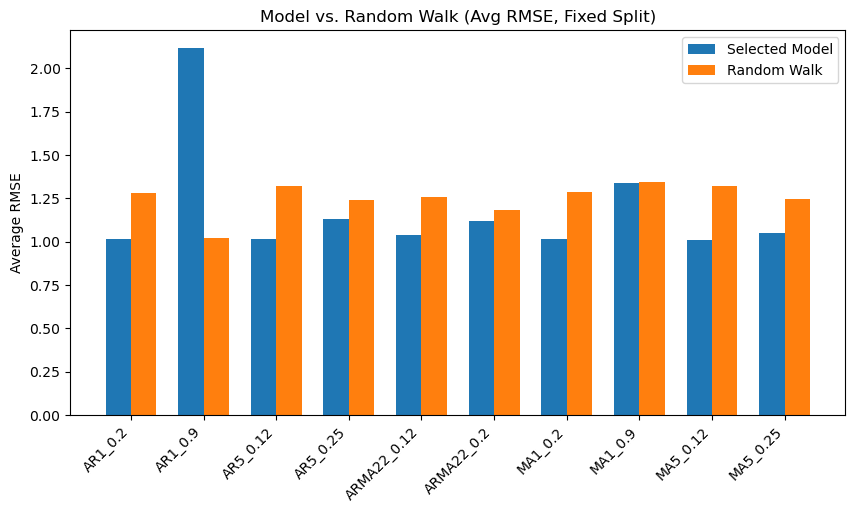

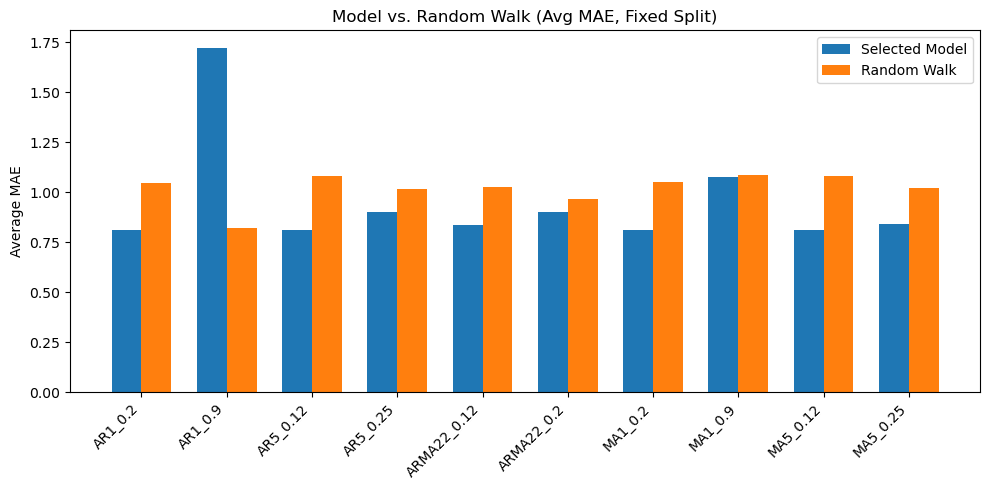

In [11]:
# STEP4
# Model vs RW

# Fixed Method
import numpy as np
import pandas as pd
from pathlib import Path
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Models determined by BIC
bic_models = {
    'AR1_0.2':  ('AR', 1, 0),
    'AR1_0.9':  ('AR', 1, 0),
    'AR5_0.12': ('ARMA', 1, 1),
    'AR5_0.25': ('ARMA', 1, 1),
    'ARMA22_0.12': ('AR', 1, 0),
    'ARMA22_0.2':  ('AR', 1, 0),
    'MA1_0.2':  ('MA', 0, 1),
    'MA1_0.9':  ('MA', 0, 1),
    'MA5_0.12': ('MA', 0, 1),
    'MA5_0.25': ('AR', 2, 0),  # AR(2) as determined
}

seeds = [42, 50, 100, 123, 200, 300, 456, 500, 777, 1000]
n_train, n_test = 400, 100
result_rows = []

for key, (model_type, p, q) in bic_models.items():
    family, coef = key.split('_')
    mse_list = []
    mse_list_rw = []
    mae_list = []          
    mae_list_rw = []
    for seed in seeds:
        # data load
        fpath = f"{family}/{coef}/{family}_{coef}_seed{seed}.csv"
        df = pd.read_csv(fpath)
        y = df['Value'].values
        train, test = y[:n_train], y[n_train:]
        
        # 1. Prediction
        if model_type == 'AR':
            model = ARIMA(train, order=(p,0,0)).fit()
        elif model_type == 'MA':
            model = ARIMA(train, order=(0,0,q)).fit()
        elif model_type == 'ARMA':
            model = ARIMA(train, order=(p,0,q)).fit()
        preds = model.forecast(steps=n_test)
        rmse = np.sqrt(mean_squared_error(test, preds))
        mae = mean_absolute_error(test, preds)    
        mse_list.append(rmse)
        mae_list.append(mae)                        

        
        # 2. RW prediction
        y_pred_rw = train[-1] + np.cumsum(np.zeros_like(test))  # yt = yt-1
        # y_pred[t] = y[t-1]
        rw_pred = np.empty_like(test)
        rw_pred[0] = train[-1]          
        rw_pred[1:] = test[:-1]         
        rmse_rw = np.sqrt(mean_squared_error(test, rw_pred))
        mae_rw = mean_absolute_error(test, rw_pred)     
        mse_list_rw.append(rmse_rw)
        mae_list_rw.append(mae_rw)                      

    
    # mean rmse and mae
    avg_rmse = np.mean(mse_list)
    avg_rmse_rw = np.mean(mse_list_rw)
    avg_mae = np.mean(mae_list)           
    avg_mae_rw = np.mean(mae_list_rw)     
    result_rows.append([family, coef, avg_rmse, avg_rmse_rw, avg_mae, avg_mae_rw])

# result DataFrame
rmse_df = pd.DataFrame(result_rows, columns=['Model', 'Coef', 'Model_RMSE', 'RW_RMSE', 'Model_MAE', 'RW_MAE'])
print(rmse_df)


import matplotlib.pyplot as plt
import numpy as np

labels = [f"{row['Model']}_{row['Coef']}" for idx, row in rmse_df.iterrows()]
x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10,5))
rects1 = ax.bar(x - width/2, rmse_df['Model_RMSE'], width, label='Selected Model')
rects2 = ax.bar(x + width/2, rmse_df['RW_RMSE'], width, label='Random Walk')

ax.set_ylabel("Average RMSE")
ax.set_title("Model vs. Random Walk (Avg RMSE, Fixed Split)")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.legend()

# MAE
labels = [f"{row['Model']}_{row['Coef']}" for idx, row in rmse_df.iterrows()]
x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10,5))
rects1 = ax.bar(x - width/2, rmse_df['Model_MAE'], width, label='Selected Model')
rects2 = ax.bar(x + width/2, rmse_df['RW_MAE'], width, label='Random Walk')

ax.set_ylabel("Average MAE")
ax.set_title("Model vs. Random Walk (Avg MAE, Fixed Split)")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.legend()

plt.tight_layout()
plt.show()

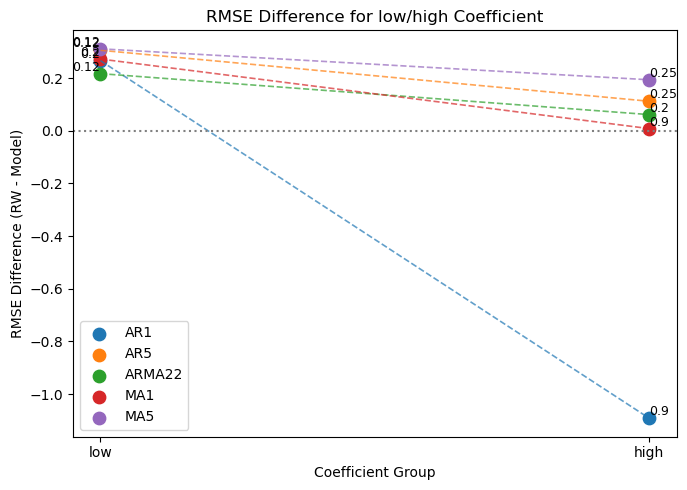

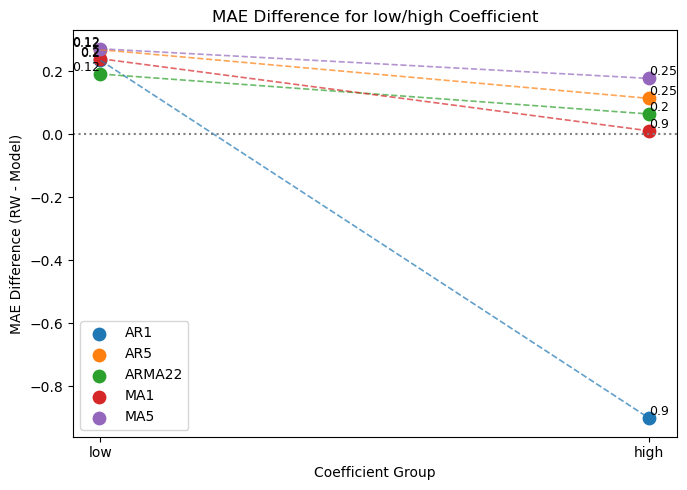

In [12]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 
data = [
    ['AR1', 0.2, 1.015998, 1.281913],
    ['AR1', 0.9, 2.114811, 1.023078],
    ['AR5', 0.12, 1.016046, 1.321369],
    ['AR5', 0.25, 1.130133, 1.241901],
    ['ARMA22', 0.12, 1.040100, 1.256720],
    ['ARMA22', 0.2, 1.121343, 1.182426],
    ['MA1', 0.2, 1.015448, 1.287496],
    ['MA1', 0.9, 1.339145, 1.347101],
    ['MA5', 0.12, 1.010936, 1.321829],
    ['MA5', 0.25, 1.053244, 1.246560]
]
df = pd.DataFrame(data, columns=['Model', 'Coef', 'Model_RMSE', 'RW_RMSE'])
df['RMSE_DIFF'] = df['RW_RMSE'] - df['Model_RMSE']

# low: x=0, high: x=1
coef_map = {}
for model in df['Model'].unique():
    coefs = sorted(df[df['Model']==model]['Coef'].values)
    coef_map[(model, coefs[0])] = 0   # low
    coef_map[(model, coefs[1])] = 1   # high
df['x'] = df.apply(lambda row: coef_map[(row['Model'], row['Coef'])], axis=1)

# Color
model_list = sorted(df['Model'].unique())
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple']

plt.figure(figsize=(7,5))

for model, color in zip(model_list, colors):
    plot_df = df[df['Model'] == model]
    x = plot_df['x'].values
    y = plot_df['RMSE_DIFF'].values
    plt.scatter(x, y, color=color, label=model, s=80)
    plt.plot(x, y, color=color, linestyle='dashed', linewidth=1.2, alpha=0.7)
    # 
    for idx, (xv, yv, coefval) in enumerate(zip(x, y, plot_df['Coef'])):
        plt.text(xv, yv, f"{coefval}", fontsize=9, ha='right' if xv==0 else 'left', va='bottom')

plt.xticks([0,1], ['low', 'high'])
plt.axhline(0, color='gray', linestyle='dotted')
plt.xlabel('Coefficient Group')
plt.ylabel('RMSE Difference (RW - Model)')
plt.title('RMSE Difference for low/high Coefficient')
plt.legend()
plt.tight_layout()
plt.show()


import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# data
data_mae = [
    ['AR1',   0.2, 0.812894, 1.047365],
    ['AR1',   0.9, 1.722425, 0.821124],
    ['AR5',  0.12, 0.810843, 1.079076],
    ['AR5',  0.25, 0.902307, 1.015951],
    ['ARMA22',0.12,0.835827, 1.026818],
    ['ARMA22',0.2, 0.901436, 0.965497],
    ['MA1',   0.2, 0.812064, 1.051548],
    ['MA1',   0.9, 1.075243, 1.085903],
    ['MA5',  0.12, 0.808559, 1.079531],
    ['MA5',  0.25, 0.842699, 1.019727]
]
df = pd.DataFrame(data_mae, columns=['Model', 'Coef', 'Model_MAE', 'RW_MAE'])
df['MAE_DIFF'] = df['RW_MAE'] - df['Model_MAE']

# low: x=0, high: x=1로
coef_map = {}
for model in df['Model'].unique():
    coefs = sorted(df[df['Model'] == model]['Coef'].values)
    coef_map[(model, coefs[0])] = 0   # low
    coef_map[(model, coefs[1])] = 1   # high
df['x'] = df.apply(lambda row: coef_map[(row['Model'], row['Coef'])], axis=1)

# 
model_list = sorted(df['Model'].unique())
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple']

plt.figure(figsize=(7,5))

for model, color in zip(model_list, colors):
    plot_df = df[df['Model'] == model]
    x = plot_df['x'].values
    y = plot_df['MAE_DIFF'].values
    plt.scatter(x, y, color=color, label=model, s=80)
    plt.plot(x, y, color=color, linestyle='dashed', linewidth=1.2, alpha=0.7)
    # 
    for xv, yv, coefval in zip(x, y, plot_df['Coef']):
        plt.text(xv, yv, f"{coefval}", fontsize=9,
                 ha='right' if xv == 0 else 'left', va='bottom')

plt.xticks([0, 1], ['low', 'high'])
plt.axhline(0, color='gray', linestyle='dotted')
plt.xlabel('Coefficient Group')
plt.ylabel('MAE Difference (RW - Model)')
plt.title('MAE Difference for low/high Coefficient')
plt.legend()
plt.tight_layout()
plt.show()



    Model  Coef  Model_RMSE   RW_RMSE  Model_MAE    RW_MAE
0     AR1   0.2    0.996868  1.281913   0.799283  1.047365
1     AR1   0.9    0.998231  1.023078   0.799575  0.821124
2     AR5  0.12    1.001222  1.321369   0.801692  1.079076
3     AR5  0.25    1.000809  1.241901   0.802664  1.015951
4  ARMA22  0.12    1.004031  1.256720   0.808248  1.026818
5  ARMA22   0.2    1.008356  1.182426   0.812651  0.965497
6     MA1   0.2    0.995973  1.287496   0.798058  1.051548
7     MA1   0.9    0.998479  1.347101   0.798744  1.085903
8     MA5  0.12    1.003370  1.321829   0.804544  1.079531
9     MA5  0.25    1.001183  1.246560   0.801647  1.019727


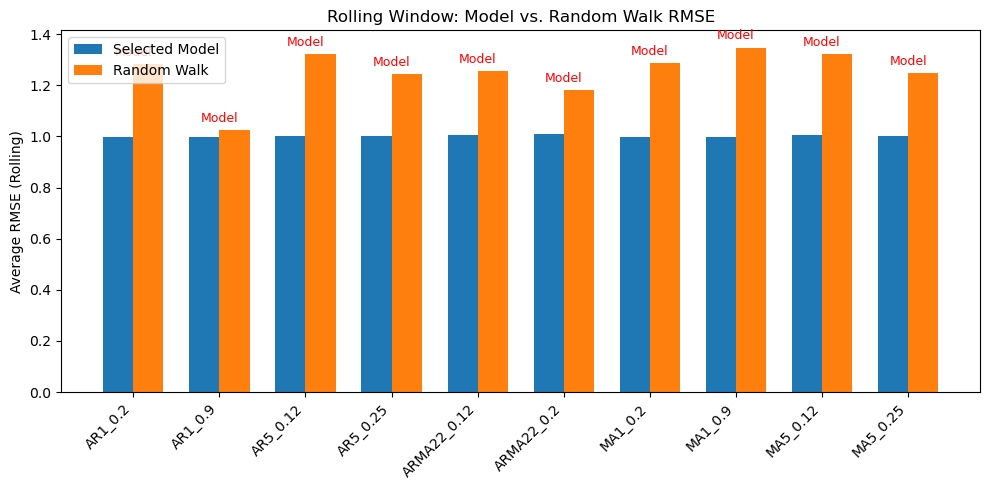

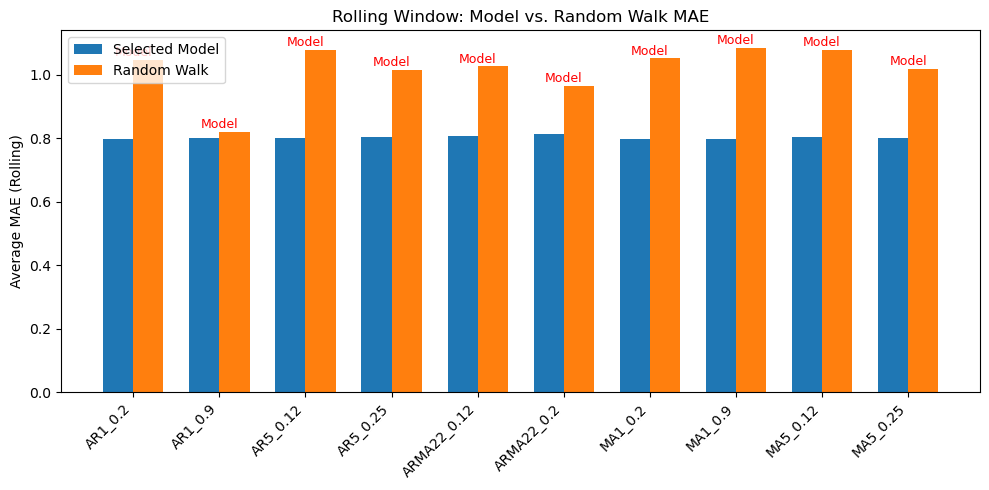

In [13]:
### Rolling Window Method

import numpy as np
import pandas as pd
from pathlib import Path
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_squared_error, mean_absolute_error

bic_models = {
    'AR1_0.2':  ('AR', 1, 0),
    'AR1_0.9':  ('AR', 1, 0),
    'AR5_0.12': ('ARMA', 1, 1),
    'AR5_0.25': ('ARMA', 1, 1),
    'ARMA22_0.12': ('AR', 1, 0),
    'ARMA22_0.2':  ('AR', 1, 0),
    'MA1_0.2':  ('MA', 0, 1),
    'MA1_0.9':  ('MA', 0, 1),
    'MA5_0.12': ('MA', 0, 1),
    'MA5_0.25': ('AR', 2, 0),
}
seeds = [42, 50, 100, 123, 200, 300, 456, 500, 777, 1000]

n_train = 400
n_total = 500
n_test = n_total - n_train  # 100
result_rows = []

for key, (model_type, p, q) in bic_models.items():
    family, coef = key.split('_')
    mse_list = []
    mse_list_rw = []
    mae_list = []          
    mae_list_rw = []       
    for seed in seeds:
        fpath = f"{family}/{coef}/{family}_{coef}_seed{seed}.csv"
        df = pd.read_csv(fpath)
        y = df['Value'].values

        preds_model = []
        preds_rw = []
        test_actuals = []

        # Rolling window 
        for t in range(n_train, n_total):
            # 
            train_window = y[t-n_train:t]  # 400 (t=400~499)
            test_true = y[t]

            # 1-step ahead forecast (model)
            if model_type == 'AR':
                model = ARIMA(train_window, order=(p,0,0)).fit()
            elif model_type == 'MA':
                model = ARIMA(train_window, order=(0,0,q)).fit()
            elif model_type == 'ARMA':
                model = ARIMA(train_window, order=(p,0,q)).fit()
            pred = model.forecast(steps=1)[0]
            preds_model.append(pred)

            # 1-step ahead forecast (random walk)
            pred_rw = train_window[-1]      
            preds_rw.append(pred_rw)

            
            test_actuals.append(test_true)

        rmse_model = np.sqrt(mean_squared_error(test_actuals, preds_model))
        rmse_rw = np.sqrt(mean_squared_error(test_actuals, preds_rw))
        mse_list.append(rmse_model)
        mse_list_rw.append(rmse_rw)
        mae_model = mean_absolute_error(test_actuals, preds_model)
        mae_rw = mean_absolute_error(test_actuals, preds_rw)
        mae_list.append(mae_model)
        mae_list_rw.append(mae_rw)             


    avg_rmse = np.mean(mse_list)
    avg_rmse_rw = np.mean(mse_list_rw)
    avg_mae = np.mean(mae_list)          
    avg_mae_rw = np.mean(mae_list_rw)
    result_rows.append([family, coef, avg_rmse, avg_rmse_rw, avg_mae, avg_mae_rw])


rmse_df_rolling = pd.DataFrame(result_rows, columns=['Model', 'Coef', 'Model_RMSE', 'RW_RMSE', 'Model_MAE', 'RW_MAE'])
print(rmse_df_rolling)


import matplotlib.pyplot as plt
import numpy as np

labels = [f"{row['Model']}_{row['Coef']}" for idx, row in rmse_df_rolling.iterrows()]
x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10,5))
rects1 = ax.bar(x - width/2, rmse_df_rolling['Model_RMSE'], width, label='Selected Model')
rects2 = ax.bar(x + width/2, rmse_df_rolling['RW_RMSE'], width, label='Random Walk')

ax.set_ylabel("Average RMSE (Rolling)")
ax.set_title("Rolling Window: Model vs. Random Walk RMSE")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.legend()

for i, (mval, rval) in enumerate(zip(rmse_df_rolling['Model_RMSE'], rmse_df_rolling['RW_RMSE'])):
    winner = 'Model' if mval < rval else 'RW'
    ax.text(i, max(mval, rval)+0.02, winner, ha='center', va='bottom', fontsize=9, color='red')

plt.tight_layout()
plt.show()

labels = [f"{row['Model']}_{row['Coef']}" for idx, row in rmse_df_rolling.iterrows()]
x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10,5))
rects1 = ax.bar(x - width/2, rmse_df_rolling['Model_MAE'], width, label='Selected Model')
rects2 = ax.bar(x + width/2, rmse_df_rolling['RW_MAE'], width, label='Random Walk')

ax.set_ylabel("Average MAE (Rolling)")
ax.set_title("Rolling Window: Model vs. Random Walk MAE")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.legend()

for i, (mval, rval) in enumerate(zip(rmse_df_rolling['Model_MAE'], rmse_df_rolling['RW_MAE'])):
    winner = 'Model' if mval < rval else 'RW'
    ax.text(i, max(mval, rval)+0.002, winner, ha='center', va='bottom',
            fontsize=9, color='red')

plt.tight_layout()
plt.show()




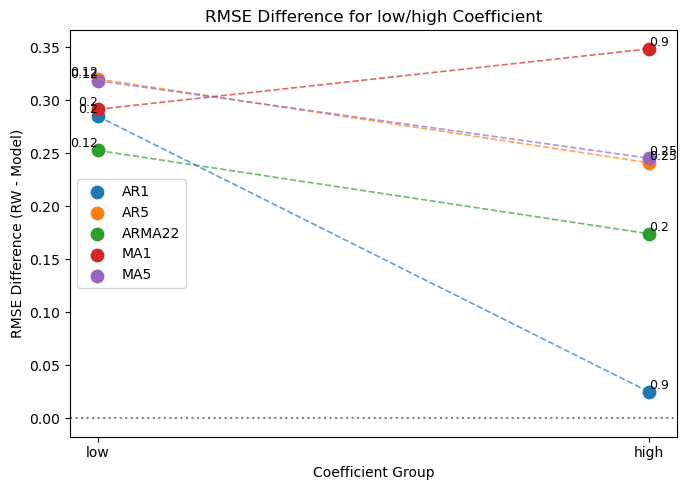

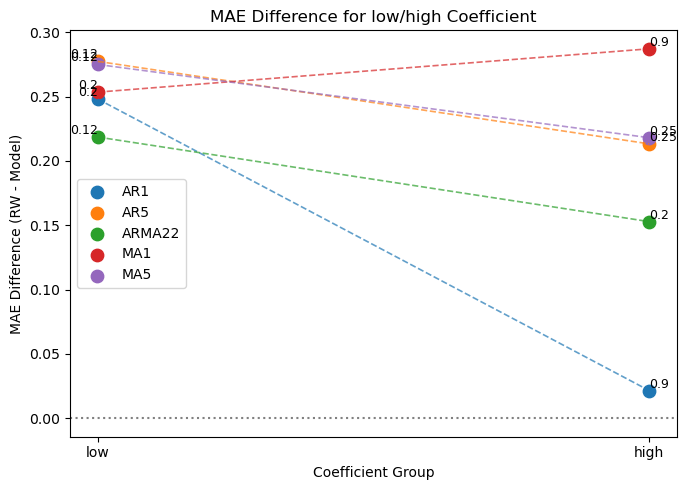

In [14]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 
data = [
    ['AR1', 0.2, 0.996868, 1.281913],
    ['AR1', 0.9, 0.998231, 1.023078],
    ['AR5', 0.12, 1.001222, 1.321369],
    ['AR5', 0.25, 1.000809, 1.241901],
    ['ARMA22', 0.12, 1.004031, 1.256720],
    ['ARMA22', 0.2, 1.008356, 1.182426],
    ['MA1', 0.2, 0.995973, 1.287496],
    ['MA1', 0.9, 0.998479, 1.347101],
    ['MA5', 0.12, 1.003370, 1.321829],
    ['MA5', 0.25, 1.001183, 1.246560]
]

df = pd.DataFrame(data, columns=['Model', 'Coef', 'Model_RMSE', 'RW_RMSE'])
df['RMSE_DIFF'] = df['RW_RMSE'] - df['Model_RMSE']

# low: x=0, high: x=1
coef_map = {}
for model in df['Model'].unique():
    coefs = sorted(df[df['Model']==model]['Coef'].values)
    coef_map[(model, coefs[0])] = 0   # low
    coef_map[(model, coefs[1])] = 1   # high
df['x'] = df.apply(lambda row: coef_map[(row['Model'], row['Coef'])], axis=1)


model_list = sorted(df['Model'].unique())
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple']

plt.figure(figsize=(7,5))

for model, color in zip(model_list, colors):
    plot_df = df[df['Model'] == model]
    x = plot_df['x'].values
    y = plot_df['RMSE_DIFF'].values
    plt.scatter(x, y, color=color, label=model, s=80)
    plt.plot(x, y, color=color, linestyle='dashed', linewidth=1.2, alpha=0.7)
    
    for idx, (xv, yv, coefval) in enumerate(zip(x, y, plot_df['Coef'])):
        plt.text(xv, yv, f"{coefval}", fontsize=9, ha='right' if xv==0 else 'left', va='bottom')

plt.xticks([0,1], ['low', 'high'])
plt.axhline(0, color='gray', linestyle='dotted')
plt.xlabel('Coefficient Group')
plt.ylabel('RMSE Difference (RW - Model)')
plt.title('RMSE Difference for low/high Coefficient')
plt.legend()
plt.tight_layout()
plt.show()


import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 
data_mae = [
    ['AR1',   0.2, 0.799283, 1.047365],
    ['AR1',   0.9, 0.799575, 0.821124],
    ['AR5',  0.12, 0.801692, 1.079076],
    ['AR5',  0.25, 0.802664, 1.015951],
    ['ARMA22',0.12,0.808248, 1.026818],
    ['ARMA22',0.2, 0.812651, 0.965497],
    ['MA1',   0.2, 0.798058, 1.051548],
    ['MA1',   0.9, 0.798744, 1.085903],
    ['MA5',  0.12, 0.804544, 1.079531],
    ['MA5',  0.25, 0.801647, 1.019727]
]
df = pd.DataFrame(data_mae, columns=['Model', 'Coef', 'Model_MAE', 'RW_MAE'])
df['MAE_DIFF'] = df['RW_MAE'] - df['Model_MAE']

# low: x=0, high: x=1
coef_map = {}
for model in df['Model'].unique():
    coefs = sorted(df[df['Model'] == model]['Coef'].values)
    coef_map[(model, coefs[0])] = 0   # low
    coef_map[(model, coefs[1])] = 1   # high
df['x'] = df.apply(lambda row: coef_map[(row['Model'], row['Coef'])], axis=1)


model_list = sorted(df['Model'].unique())
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple']

plt.figure(figsize=(7,5))

for model, color in zip(model_list, colors):
    plot_df = df[df['Model'] == model]
    x = plot_df['x'].values
    y = plot_df['MAE_DIFF'].values
    plt.scatter(x, y, color=color, label=model, s=80)
    plt.plot(x, y, color=color, linestyle='dashed', linewidth=1.2, alpha=0.7)
    
    for xv, yv, coefval in zip(x, y, plot_df['Coef']):
        plt.text(xv, yv, f"{coefval}", fontsize=9,
                 ha='right' if xv == 0 else 'left', va='bottom')

plt.xticks([0, 1], ['low', 'high'])
plt.axhline(0, color='gray', linestyle='dotted')
plt.xlabel('Coefficient Group')
plt.ylabel('MAE Difference (RW - Model)')
plt.title('MAE Difference for low/high Coefficient')
plt.legend()
plt.tight_layout()
plt.show()



In [15]:
### Recursive Method

import numpy as np
import pandas as pd
from pathlib import Path
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_squared_error, mean_absolute_error

bic_models = {
    'AR1_0.2':  ('AR', 1, 0),
    'AR1_0.9':  ('AR', 1, 0),
    'AR5_0.12': ('ARMA', 1, 1),
    'AR5_0.25': ('ARMA', 1, 1),
    'ARMA22_0.12': ('AR', 1, 0),
    'ARMA22_0.2':  ('AR', 1, 0),
    'MA1_0.2':  ('MA', 0, 1),
    'MA1_0.9':  ('MA', 0, 1),
    'MA5_0.12': ('MA', 0, 1),
    'MA5_0.25': ('AR', 2, 0),
}
seeds = [42, 50, 100, 123, 200, 300, 456, 500, 777, 1000]

n_train = 400
n_total = 500
n_test = n_total - n_train  # 100
result_rows = []

for key, (model_type, p, q) in bic_models.items():
    family, coef = key.split('_')
    mse_list = []
    mse_list_rw = []
    mae_list = []          
    mae_list_rw = []       
    for seed in seeds:
        fpath = f"{family}/{coef}/{family}_{coef}_seed{seed}.csv"
        df = pd.read_csv(fpath)
        y = df['Value'].values

        preds_model = []
        preds_rw = []
        test_actuals = []

        # Recursive: 
        for t in range(n_train, n_total):
            train_window = y[:t]     # 0~t-1
            test_true = y[t]

            # 1-step ahead forecast (model)
            if model_type == 'AR':
                model = ARIMA(train_window, order=(p,0,0)).fit()
            elif model_type == 'MA':
                model = ARIMA(train_window, order=(0,0,q)).fit()
            elif model_type == 'ARMA':
                model = ARIMA(train_window, order=(p,0,q)).fit()
            pred = model.forecast(steps=1)[0]
            preds_model.append(pred)

            # 1-step ahead forecast (random walk)
            pred_rw = train_window[-1]
            preds_rw.append(pred_rw)

            test_actuals.append(test_true)

        rmse_model = np.sqrt(mean_squared_error(test_actuals, preds_model))
        rmse_rw = np.sqrt(mean_squared_error(test_actuals, preds_rw))
        mse_list.append(rmse_model)
        mse_list_rw.append(rmse_rw)
        mae_model = mean_absolute_error(test_actuals, preds_model)
        mae_rw = mean_absolute_error(test_actuals, preds_rw)
        mae_list.append(mae_model)
        mae_list_rw.append(mae_rw)

    avg_rmse = np.mean(mse_list)
    avg_rmse_rw = np.mean(mse_list_rw)
    avg_mae = np.mean(mae_list)           
    avg_mae_rw = np.mean(mae_list_rw)
    result_rows.append([family, coef, avg_rmse, avg_rmse_rw, avg_mae, avg_mae_rw])

rmse_df_recursive = pd.DataFrame(result_rows, columns=['Model', 'Coef', 'Model_RMSE', 'RW_RMSE', 'Model_MAE', 'RW_MAE'])
print(rmse_df_recursive)


    Model  Coef  Model_RMSE   RW_RMSE  Model_MAE    RW_MAE
0     AR1   0.2    0.995885  1.281913   0.798192  1.047365
1     AR1   0.9    0.996708  1.023078   0.797690  0.821124
2     AR5  0.12    0.999788  1.321369   0.800561  1.079076
3     AR5  0.25    0.999269  1.241901   0.800629  1.015951
4  ARMA22  0.12    1.002804  1.256720   0.807058  1.026818
5  ARMA22   0.2    1.006920  1.182426   0.811155  0.965497
6     MA1   0.2    0.995197  1.287496   0.797409  1.051548
7     MA1   0.9    0.997221  1.347101   0.797330  1.085903
8     MA5  0.12    1.002254  1.321829   0.803758  1.079531
9     MA5  0.25    0.999143  1.246560   0.800319  1.019727


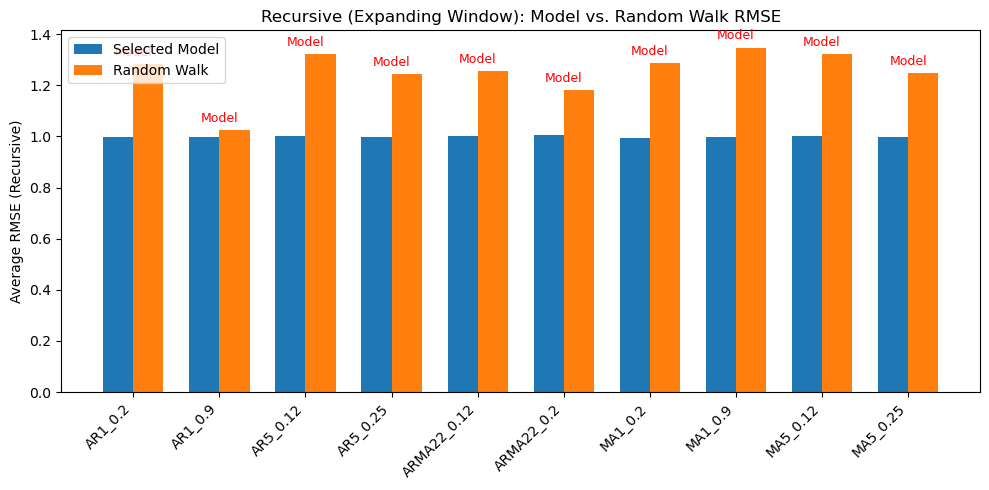

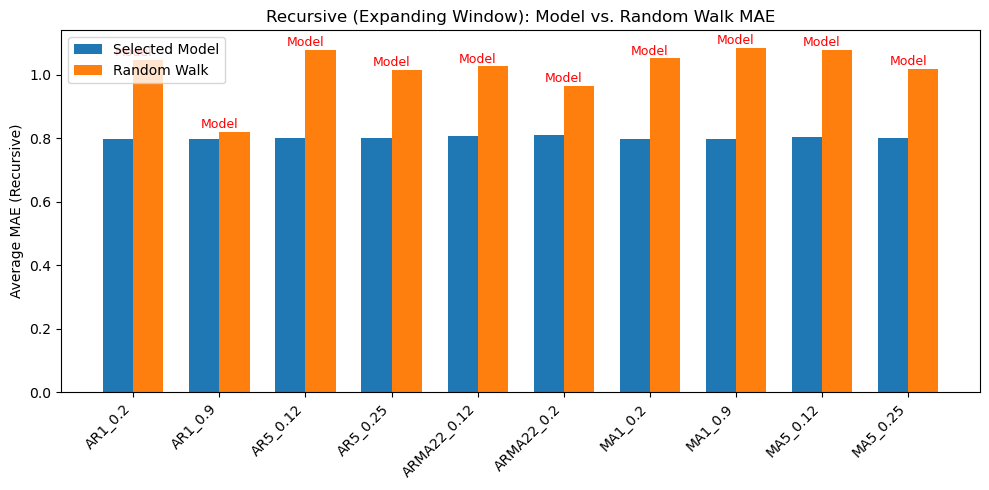

In [16]:
import matplotlib.pyplot as plt
import numpy as np

labels = [f"{row['Model']}_{row['Coef']}" for idx, row in rmse_df_recursive.iterrows()]
x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10,5))
rects1 = ax.bar(x - width/2, rmse_df_recursive['Model_RMSE'], width, label='Selected Model')
rects2 = ax.bar(x + width/2, rmse_df_recursive['RW_RMSE'], width, label='Random Walk')

ax.set_ylabel("Average RMSE (Recursive)")
ax.set_title("Recursive (Expanding Window): Model vs. Random Walk RMSE")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.legend()

for i, (mval, rval) in enumerate(zip(rmse_df_recursive['Model_RMSE'], rmse_df_recursive['RW_RMSE'])):
    winner = 'Model' if mval < rval else 'RW'
    ax.text(i, max(mval, rval)+0.02, winner, ha='center', va='bottom', fontsize=9, color='red')

plt.tight_layout()
plt.show()

import matplotlib.pyplot as plt
import numpy as np

labels = [f"{row['Model']}_{row['Coef']}" for idx, row in rmse_df_recursive.iterrows()]
x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10,5))
rects1 = ax.bar(x - width/2, rmse_df_recursive['Model_MAE'], width, label='Selected Model')
rects2 = ax.bar(x + width/2, rmse_df_recursive['RW_MAE'], width, label='Random Walk')

ax.set_ylabel("Average MAE (Recursive)")
ax.set_title("Recursive (Expanding Window): Model vs. Random Walk MAE")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.legend()

for i, (mval, rval) in enumerate(zip(rmse_df_recursive['Model_MAE'], rmse_df_recursive['RW_MAE'])):
    winner = 'Model' if mval < rval else 'RW'
    ax.text(i, max(mval, rval)+0.002, winner,
            ha='center', va='bottom', fontsize=9, color='red')

plt.tight_layout()
plt.show()



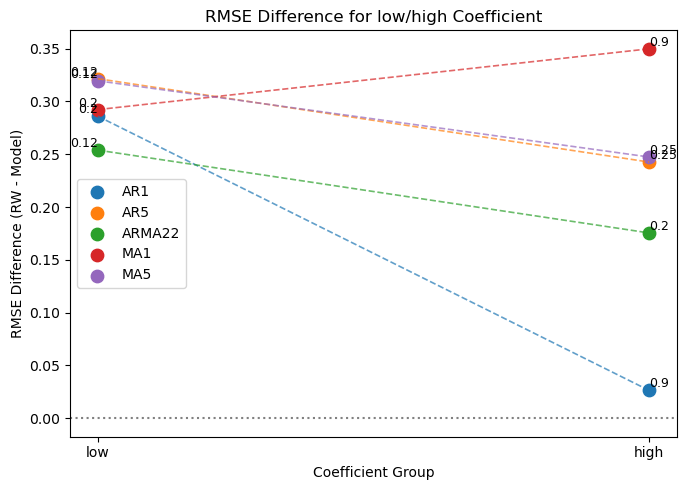

In [17]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

#
data = [
    ['AR1', 0.2, 0.995885, 1.281913],
    ['AR1', 0.9, 0.996708, 1.023078],
    ['AR5', 0.12, 0.999788, 1.321369],
    ['AR5', 0.25, 0.999269, 1.241901],
    ['ARMA22', 0.12, 1.002804, 1.256720],
    ['ARMA22', 0.2, 1.006920, 1.182426],
    ['MA1', 0.2, 0.995197, 1.287496],
    ['MA1', 0.9, 0.997221, 1.347101],
    ['MA5', 0.12, 1.002254, 1.321829],
    ['MA5', 0.25, 0.999143, 1.246560]
]

df = pd.DataFrame(data, columns=['Model', 'Coef', 'Model_RMSE', 'RW_RMSE'])
df['RMSE_DIFF'] = df['RW_RMSE'] - df['Model_RMSE']

# low: x=0, high: x=1
coef_map = {}
for model in df['Model'].unique():
    coefs = sorted(df[df['Model']==model]['Coef'].values)
    coef_map[(model, coefs[0])] = 0   # low
    coef_map[(model, coefs[1])] = 1   # high
df['x'] = df.apply(lambda row: coef_map[(row['Model'], row['Coef'])], axis=1)


model_list = sorted(df['Model'].unique())
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple']

plt.figure(figsize=(7,5))

for model, color in zip(model_list, colors):
    plot_df = df[df['Model'] == model]
    x = plot_df['x'].values
    y = plot_df['RMSE_DIFF'].values
    plt.scatter(x, y, color=color, label=model, s=80)
    plt.plot(x, y, color=color, linestyle='dashed', linewidth=1.2, alpha=0.7)
    
    for idx, (xv, yv, coefval) in enumerate(zip(x, y, plot_df['Coef'])):
        plt.text(xv, yv, f"{coefval}", fontsize=9, ha='right' if xv==0 else 'left', va='bottom')

plt.xticks([0,1], ['low', 'high'])
plt.axhline(0, color='gray', linestyle='dotted')
plt.xlabel('Coefficient Group')
plt.ylabel('RMSE Difference (RW - Model)')
plt.title('RMSE Difference for low/high Coefficient')
plt.legend()
plt.tight_layout()
plt.show()


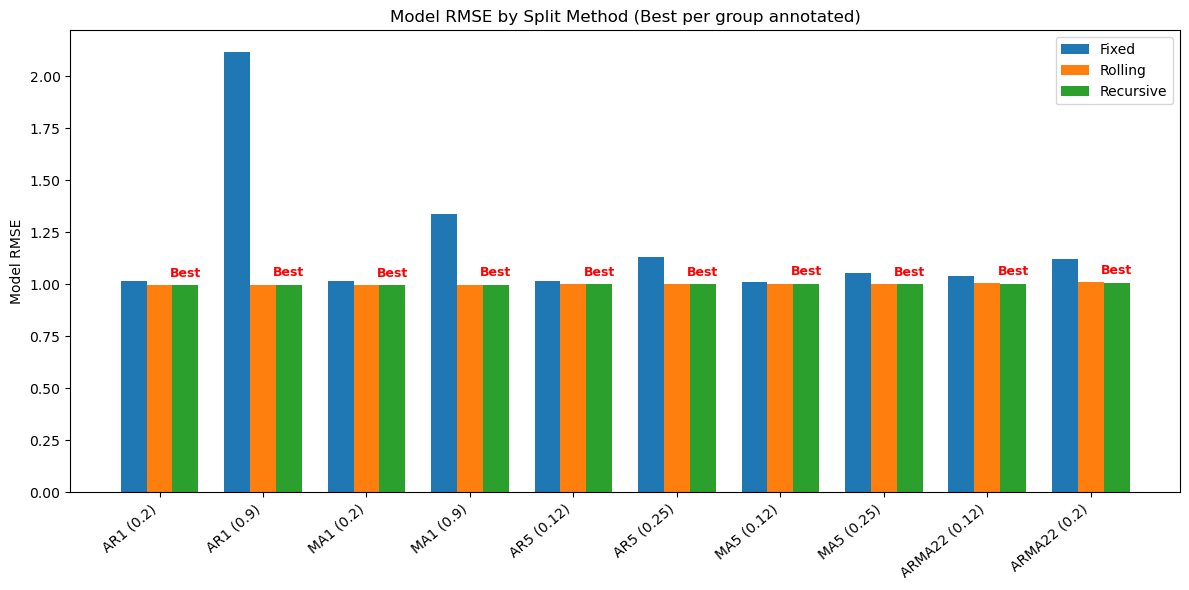

In [18]:
### Fixed vs Rolling vs Recursive

import matplotlib.pyplot as plt
import numpy as np


models = ['AR1', 'MA1', 'AR5', 'MA5', 'ARMA22']
coefs = {'AR1': [0.2, 0.9], 'MA1': [0.2, 0.9], 
         'AR5': [0.12, 0.25], 'MA5': [0.12, 0.25], 'ARMA22': [0.12, 0.2]}

# results
fixed_rmse   = [1.015998, 2.114811, 1.015448, 1.339145, 1.016046, 1.130133, 1.010936, 1.053244, 1.040100, 1.121343]
rolling_rmse = [0.996868, 0.998231, 0.995973, 0.998479, 1.001222, 1.000809, 1.003370, 1.001183, 1.004031, 1.008356]
recurs_rmse  = [0.995885, 0.996708, 0.995197, 0.997221, 0.999788, 0.999269, 1.002254, 0.999143, 1.002804, 1.006920]

# x label
xlabels = []
for m in models:
    for c in coefs[m]:
        xlabels.append(f"{m} ({c})")

n = len(xlabels)
x = np.arange(n)
bar_width = 0.25

plt.figure(figsize=(12,6))

bars1 = plt.bar(x - bar_width, fixed_rmse, width=bar_width, label='Fixed')
bars2 = plt.bar(x, rolling_rmse, width=bar_width, label='Rolling')
bars3 = plt.bar(x + bar_width, recurs_rmse, width=bar_width, label='Recursive')

plt.xticks(x, xlabels, rotation=40, ha='right')
plt.ylabel("Model RMSE")
plt.title("Model RMSE by Split Method (Best per group annotated)")
plt.legend()

# Annotate: 
for i in range(n):
    vals = [fixed_rmse[i], rolling_rmse[i], recurs_rmse[i]]
    minval = min(vals)
    method = ['Fixed', 'Rolling', 'Recursive'][vals.index(minval)]
    bar_collections = [bars1, bars2, bars3]
    bar = bar_collections[vals.index(minval)][i]
    plt.annotate(f'Best',
                 (bar.get_x() + bar.get_width()/2, bar.get_height()),
                 ha='center', va='bottom', color='red',
                 fontweight='bold', fontsize=9, xytext=(0,4), textcoords='offset points')

plt.tight_layout()
plt.show()
